In [ ]:
# from selenium import webdriver

# driver_path = './chromedriver.exe' # windows
# # driver_path = './chromedriver'     # mac

# cService = webdriver.ChromeService(executable_path=driver_path)
# driver = webdriver.Chrome(service = cService)
# driver.implicitly_wait(3) # waiting 3 seconds

In [15]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service)
driver.implicitly_wait(3)

In [16]:
company = input("기업명을 입력하세요: ")

url = f"https://search.naver.com/search.naver?where=news&query={company}"
driver.get(url)
driver.implicitly_wait(2)

In [17]:
from time import sleep
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys 

def get_article_links_scroll(max_articles=40, max_scroll=20):
    urls = set() # set으로 스크롤 후 기사들 전부 긁어올 때 이전의 중복기사 제거
    body = driver.find_element(By.TAG_NAME, "body") # 몸통잡기 tag_name 광범위하게 포함

    for i in range(max_scroll):
        # 1) 현재까지 로딩된 기사에서 링크 수집
        url_list= driver.find_elements(By.PARTIAL_LINK_TEXT, '네이버뉴스')

        for url in url_list:
            href = url.get_attribute("href")
            urls.add(href)
            if len(urls) >= max_articles:
                return list(urls)
        
        # 2) 페이지 아래로 스크롤
        body.send_keys(Keys.END)
        sleep(1)  # 기사 추가 로딩 기다림

    return list(urls)

urls = get_article_links_scroll(max_articles=50, max_scroll=20)
print("모은 기사 링크 수:", len(urls))

모은 기사 링크 수: 50


In [ ]:
import pandas as pd

def get_article_content(urls):
    data_dict = {
    'url': [],
    'title': [],
    'text': [],
    'publisher': [],
    'dt': []
}
    for url in urls:
        driver.get(url)
        sleep(0.7)

        try:
            title = driver.find_element(By.CSS_SELECTOR, "#title_area").text
        except:
            title = ""
            
        try:
            text = driver.find_element(By.CSS_SELECTOR, "#dic_area").text
        except:
            text = ""

        try:
            publisher = driver.find_element(By.CSS_SELECTOR, "img.media_end_head_top_logo_img")
            publisher = publisher.get_attribute('alt')
        except:
            publisher = ""

        try:
            dt = driver.find_element(By.CSS_SELECTOR, "span.media_end_head_info_datestamp_time")
            dt = dt.get_attribute('data-date-time')
        except:
            dt = ""
        
        data_dict['url'].append(url)
        data_dict['title'].append(title)
        data_dict['text'].append(text)
        data_dict['publisher'].append(publisher)
        data_dict['dt'].append(dt)
    
    data_df = pd.DataFrame(data_dict)
    data_df['dt'] = pd.to_datetime(data_df['dt'], errors='coerce')
    return data_df
    
data_df = get_article_content(urls)
print("수집된 기사 수:", len(data_df))

본문까지 수집된 기사 수: 50


In [19]:
data_df.head()

,url,title,text,publisher,dt
0,https://n.news.naver.com/mnews/article/005/000...,쿠팡 “정부 지시 따라 조사”… 경찰 “협의 없었다”,"셀프 면죄부 논란에 반박 나서\n정부 “쿠팡 자체 발표, 국민 혼란”\n사진은 26...",국민일보,2025-12-26 18:47:09
1,https://n.news.naver.com/mnews/article/421/000...,"셀프조사 논란 쿠팡 ""정부와 공조했다""…타임라인 공개하며 반박","""사전 협의·공문 통한 협력 조사…불필요한 불안감 조성 우려""\n(쿠팡 제공)\n\...",뉴스1,2025-12-26 15:06:24
2,https://n.news.naver.com/mnews/article/028/000...,쿠팡 “정부 지시 따라 유출자 접촉…자체조사 아냐” 반박,쿠팡 제공\n\n개인정보 유출 정보가 외부로 전송된 정황이 없다는 쿠팡의 발표에 대...,한겨레,2025-12-26 15:40:14
3,https://n.news.naver.com/mnews/article/055/000...,"쿠팡, 납품업체서 판매촉진비·장려금 2조 3천억 넘게 걷었다",최근 개인정보 대량 유출 사태로 물의를 일으킨 쿠팡이 작년에 납품업체로부터 2조 3...,SBS,2025-12-25 13:11:15
4,https://n.news.naver.com/mnews/article/052/000...,"쿠팡 ""자체 조사 아냐...정부와 매일 협력하며 진행""","쿠팡은 정보 유출자에 대한 '자체 조사'를 벌였다는 의혹이 커지자, 사전에 정부와 ...",YTN,2025-12-26 15:35:47


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from konlpy.tag import Okt

def get_words_ko(text, stopwords=None):
    okt = Okt()
    tagged = okt.pos(text, 
                     stem=True, 
                     norm=True)
    filtered = [w for w, pos in tagged if pos[0] in ['N']]
    filtered = [w for w in filtered if len(w) > 1] 
    
    if stopwords is not None:
        filtered = [w for w in filtered if w not in stopwords]
    return filtered

# 커스텀 가능
custom_stopwords = [company,'이미지','편집','기업','통해','기존','기능','흐름','산업','사용자','기반','올해','공유','기준','전망','저장','이번','대상','적용','대비','주변','현재','위해','경우','공식','지난','순차','라며','주요','이상','크게','업계','여러','이후','상태','더욱','포함','보고','대폭','한층','특정','거나','해당','또한','연합뉴스','때문','하량','대한민국','실제','사진','제공']
data_df['word'] = data_df['text'].apply(lambda text: get_words_ko(text, stopwords=custom_stopwords))

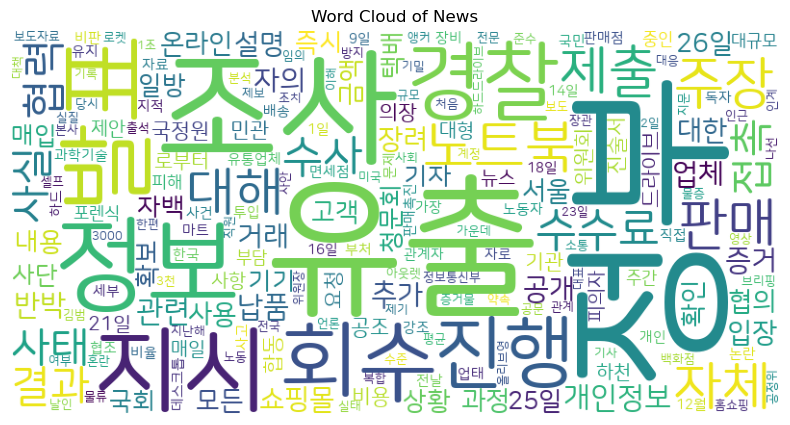

[('정부', 516),
 ('유출', 373),
 ('조사', 291),
 ('정보', 151),
 ('발표', 137),
 ('지시', 137),
 ('회수', 108),
 ('경찰', 103),
 ('진행', 95),
 ('노트북', 91),
 ('주장', 89),
 ('판매', 85),
 ('자체', 84),
 ('대해', 84),
 ('제출', 83),
 ('수수료', 81),
 ('수사', 78),
 ('협력', 77),
 ('사태', 74),
 ('결과', 74),
 ('사실', 71),
 ('접촉', 70),
 ('개인정보', 65),
 ('관련', 64),
 ('자의', 61),
 ('추가', 60),
 ('반박', 59),
 ('납품', 59),
 ('거래', 59),
 ('증거', 58),
 ('공개', 57),
 ('업체', 57),
 ('장려', 55),
 ('쇼핑몰', 55),
 ('입장', 54),
 ('대한', 53),
 ('설명', 52),
 ('과정', 48),
 ('온라인', 47),
 ('26일', 46),
 ('서울', 46),
 ('협의', 46),
 ('사용', 46),
 ('일방', 44),
 ('고객', 43),
 ('내용', 43),
 ('기자', 43),
 ('자백', 43),
 ('기기', 42),
 ('상황', 41),
 ('모든', 41),
 ('25일', 40),
 ('즉시', 40),
 ('확인', 40),
 ('확보', 39),
 ('금액', 38),
 ('택배', 38),
 ('국회', 36),
 ('청문회', 36),
 ('사단', 35),
 ('매입', 35),
 ('국정원', 35),
 ('요청', 34),
 ('민관', 34),
 ('합동', 34),
 ('기관', 34),
 ('비용', 34),
 ('의장', 34),
 ('공조', 33),
 ('진술서', 33),
 ('드라이브', 33),
 ('위원회', 33),
 ('로부터', 32),
 ('21일', 32),
 ('제안', 30),
 

In [21]:
from collections import Counter
import itertools

def draw_wordcloud(words_all, title=None):
    word_freq = Counter(words_all)
    words_final = {w:c for w,c in word_freq.items() if c >= 10}
    words_final = {w:c for w,c in words_final.items() if w not in company}
    wordcloud = WordCloud(font_path='./NanumSquareRoundR.ttf', 
                          width=800, height=400, background_color='white').generate_from_frequencies(words_final)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.savefig(f'{company}wordcloud.png')
    plt.show()

    return sorted(words_final.items(), key=lambda x:x[1], reverse=True) # 가장많은 빈도 확인
    
def flatten_list(list_of_lists):
    return list(itertools.chain.from_iterable(list_of_lists))

words_all = flatten_list(data_df['word'].tolist()) # 리스트의 리스트로 

draw_wordcloud(words_all, title='Word Cloud of News')

In [22]:
data_df.to_csv('naver_news.csv', index=False, encoding='utf-8-sig')